In [19]:
import pandas
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.gridspec import GridSpec
import typing as t
data = pandas.read_csv("../report.csv")
data["succeeded"] = data["succeeded"].astype(int)
data_per_sim = data.groupby(['n_robots', 'algorithm', 'agent_id']).sum().reset_index()
avg_per_sim = data_per_sim.drop(columns="agent_id").groupby(['n_robots', 'algorithm']).mean()
std_per_sim = data_per_sim.drop(columns="agent_id").groupby(['n_robots', 'algorithm']).std()

data = data.drop(columns=["agent_id"])
success_rates = data.groupby(['n_robots','algorithm'])['succeeded'].mean().reset_index()

data_successes = data[data["succeeded"] == 1]

# data = data.drop(columns=["succeeded"])
# data_successes = data_successes.drop(columns=["succeeded"])


In [20]:
data

,n_robots,algorithm,succeeded,distance_traveled,n_transfers,planning_time,n_planning_timeouts,postponements,replans,transfer_distance_traveled,n_conflicts,n_rr_conflicts,n_steps
0,1,namo,1,971.081291,2.0,4.807959,0.0,0.0,1.0,87.426409,0.0,0.0,87.0
1,1,namo,1,1500.623706,2.0,13.920532,0.0,0.0,1.0,132.426409,0.0,0.0,131.0
2,1,namo,1,1386.427426,1.0,2.666194,0.0,0.0,1.0,36.213204,0.0,0.0,114.0
3,1,namo,1,1491.486969,1.0,8.107026,0.0,0.0,1.0,36.213204,0.0,0.0,130.0
4,1,namo,1,1475.472905,2.0,7.289442,0.0,0.0,1.0,57.426409,0.0,0.0,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
158545,7,snamo_ncr,0,0.000000,0.0,0.129941,0.0,0.0,1.0,0.000000,1.0,1.0,1.0
158546,7,snamo_ncr,0,0.000000,0.0,3.077813,0.0,0.0,1.0,0.000000,1.0,1.0,1.0
158547,7,snamo_ncr,0,0.000000,0.0,0.109499,0.0,0.0,1.0,0.000000,1.0,1.0,1.0
158548,7,snamo_ncr,1,1957.903679,0.0,4.947428,0.0,0.0,1.0,0.000000,0.0,0.0,142.0


In [21]:
avg_per_sim

succeeded  distance_traveled  n_transfers  planning_time  \
n_robots algorithm                                                              
1        namo       975.000000       8.802523e+05   593.000000    4033.751968   
         namo_ncr   975.000000       8.802523e+05   593.000000    4055.020137   
         namo_ndr   975.000000       8.802523e+05   593.000000    4055.638901   
         snamo      970.000000       9.922280e+05   377.000000    6965.501300   
         snamo_ncr  971.000000       9.997496e+05   379.000000    6972.014908   
         snamo_ndr  970.000000       9.895643e+05   379.000000    7011.531732   
2        namo       936.500000       1.449245e+06   429.500000    5773.193599   
         namo_ncr   487.500000       4.560113e+05   267.500000    3523.542277   
         namo_ndr   863.000000       1.061083e+06   415.500000    5254.153256   
         snamo      892.500000       9.721182e+05   272.000000    9968.350356   
         snamo_ncr  523.500000       5.238468e+05   192.500000    8088.087010   
         snamo_ndr  783.500000       8.131491e+05   250.500000    9898.731956   
3        namo       913.666667       1.679502e+06   376.666667    7509.379681   
         namo_ncr   343.000000       3.347429e+05   177.000000    3616.070678   
         namo_ndr   734.000000       1.101672e+06   320.666667    6519.139576   
         snamo      826.000000       1.079591e+06   233.666667   13117.871118   
         snamo_ncr  344.666667       3.407174e+05   127.333333   10422.702634   
         snamo_ndr  704.333333       8.424316e+05   208.000000   12576.697985   
4        namo       880.750000       1.957529e+06   338.000000   10196.976463   
         namo_ncr   278.500000       3.138763e+05   139.250000    3739.679692   
         namo_ndr   594.250000       9.831026e+05   246.750000    7763.322419   
         snamo      788.000000       1.181387e+06   195.750000   14681.476118   
         snamo_ncr  287.750000       2.600732e+05    96.250000   11272.732277   
         snamo_ndr  580.750000       8.519114e+05   163.000000   14092.217515   
5        namo       815.000000       2.015410e+06   308.600000   12509.260861   
         namo_ncr   208.200000       2.066673e+05    99.200000    3342.709253   
         namo_ndr   442.200000       8.278832e+05   197.000000    8206.547763   
         snamo      731.600000       1.222002e+06   166.200000   15696.770961   
         snamo_ncr  208.000000       1.848682e+05    75.800000   12975.621433   
         snamo_ndr  440.000000       6.545936e+05   120.600000   15583.654129   
6        namo       705.833333       1.879136e+06   266.166667   14173.007281   
         namo_ncr   172.333333       1.612141e+05    78.000000    3298.065341   
         namo_ndr   397.666667       7.812573e+05   156.833333    8564.554734   
         snamo      673.833333       1.250537e+06   151.000000   18144.810475   
         snamo_ncr  173.000000       1.595638e+05    55.333333   13411.948814   
         snamo_ndr  366.166667       5.842361e+05   103.666667   17261.667047   
7        namo       592.000000       1.712923e+06   219.428571   15996.187485   
         namo_ncr   155.857143       1.471254e+05    76.000000    3969.391308   
         namo_ndr   308.857143       6.084155e+05   131.142857    8985.901791   
         snamo      183.142857       3.604875e+05    41.571429    5502.860107   
         snamo_ncr  132.285714       1.259596e+05    44.857143   14462.029347   
         snamo_ndr  145.428571       2.302154e+05    39.000000    6845.090385   

                    n_planning_timeouts  postponements      replans  \
n_robots algorithm                                                    
1        namo                  6.000000       0.000000   994.000000   
         namo_ncr              6.000000       0.000000   994.000000   
         namo_ndr              6.000000       0.000000   994.000000   
         snamo                22.000000       0.000000   978.000000   
         snamo_ncr            

In [22]:
avg_per_sim.reset_index()[['n_robots', 'algorithm', 'succeeded']]

,n_robots,algorithm,succeeded
0,1,namo,975.000000
1,1,namo_ncr,975.000000
2,1,namo_ndr,975.000000
3,1,snamo,970.000000
4,1,snamo_ncr,971.000000
5,1,snamo_ndr,970.000000
6,2,namo,936.500000
7,2,namo_ncr,487.500000
8,2,namo_ndr,863.000000
9,2,snamo,892.500000


In [23]:
std_per_sim.reset_index()[['n_robots', 'algorithm', 'succeeded']]

,n_robots,algorithm,succeeded
0,1,namo,NaN
1,1,namo_ncr,NaN
2,1,namo_ndr,NaN
3,1,snamo,NaN
4,1,snamo_ncr,NaN
5,1,snamo_ndr,NaN
6,2,namo,2.121320
7,2,namo_ncr,14.849242
8,2,namo_ndr,19.798990
9,2,snamo,6.363961


In [24]:
data_successes

,n_robots,algorithm,succeeded,distance_traveled,n_transfers,planning_time,n_planning_timeouts,postponements,replans,transfer_distance_traveled,n_conflicts,n_rr_conflicts,n_steps
0,1,namo,1,971.081291,2.0,4.807959,0.0,0.0,1.0,87.426409,0.0,0.0,87.0
1,1,namo,1,1500.623706,2.0,13.920532,0.0,0.0,1.0,132.426409,0.0,0.0,131.0
2,1,namo,1,1386.427426,1.0,2.666194,0.0,0.0,1.0,36.213204,0.0,0.0,114.0
3,1,namo,1,1491.486969,1.0,8.107026,0.0,0.0,1.0,36.213204,0.0,0.0,130.0
4,1,namo,1,1475.472905,2.0,7.289442,0.0,0.0,1.0,57.426409,0.0,0.0,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
158529,7,snamo_ncr,1,45.000000,0.0,0.294587,0.0,0.0,1.0,0.000000,0.0,0.0,7.0
158532,7,snamo_ncr,1,773.345238,0.0,2.663109,0.0,0.0,1.0,0.000000,0.0,0.0,62.0
158539,7,snamo_ncr,1,187.279221,0.0,0.675372,0.0,0.0,1.0,0.000000,0.0,0.0,18.0
158542,7,snamo_ncr,1,1315.104100,1.0,8.999513,0.0,0.0,1.0,111.213204,0.0,0.0,101.0


In [25]:
success_rates

,n_robots,algorithm,succeeded
0,1,namo,0.975000
1,1,namo_ncr,0.975000
2,1,namo_ndr,0.975000
3,1,snamo,0.970000
4,1,snamo_ncr,0.971000
5,1,snamo_ndr,0.970000
6,2,namo,0.936500
7,2,namo_ncr,0.487500
8,2,namo_ndr,0.863000
9,2,snamo,0.892500


In [26]:
avg = data.groupby(['n_robots', 'algorithm']).mean()
avg_success = data_successes.groupby(['n_robots','algorithm']).mean()

In [27]:
avg

succeeded  distance_traveled  n_transfers  planning_time  \
n_robots algorithm                                                             
1        namo        0.975000         880.252336     0.593000       4.033752   
         namo_ncr    0.975000         880.252336     0.593000       4.055020   
         namo_ndr    0.975000         880.252336     0.593000       4.055639   
         snamo       0.970000         992.228023     0.377000       6.965501   
         snamo_ncr   0.971000         999.749557     0.379000       6.972015   
         snamo_ndr   0.970000         989.564337     0.379000       7.011532   
2        namo        0.936500        1449.245278     0.429500       5.773194   
         namo_ncr    0.487500         456.011256     0.267500       3.523542   
         namo_ndr    0.863000        1061.083018     0.415500       5.254153   
         snamo       0.892500         972.118210     0.272000       9.968350   
         snamo_ncr   0.523500         523.846802     0.192500       8.088087   
         snamo_ndr   0.783500         813.149126     0.250500       9.898732   
3        namo        0.913667        1679.502234     0.376667       7.509380   
         namo_ncr    0.343000         334.742949     0.177000       3.616071   
         namo_ndr    0.734000        1101.672125     0.320667       6.519140   
         snamo       0.826000        1079.590552     0.233667      13.117871   
         snamo_ncr   0.344667         340.717351     0.127333      10.422703   
         snamo_ndr   0.704333         842.431571     0.208000      12.576698   
4        namo        0.880750        1957.529291     0.338000      10.196976   
         namo_ncr    0.278500         313.876304     0.139250       3.739680   
         namo_ndr    0.594250         983.102607     0.246750       7.763322   
         snamo       0.788000        1181.387218     0.195750      14.681476   
         snamo_ncr   0.287750         260.073222     0.096250      11.272732   
         snamo_ndr   0.580750         851.911415     0.163000      14.092218   
5        namo        0.815000        2015.410093     0.308600      12.509261   
         namo_ncr    0.208200         206.667292     0.099200       3.342709   
         namo_ndr    0.442200         827.883164     0.197000       8.206548   
         snamo       0.731600        1222.002172     0.166200      15.696771   
         snamo_ncr   0.208000         184.868200     0.075800      12.975621   
         snamo_ndr   0.440000         654.593639     0.120600      15.583654   
6        namo        0.705833        1879.135564     0.266167      14.173007   
         namo_ncr    0.172333         161.214114     0.078000       3.298065   
         namo_ndr    0.397667         781.257258     0.156833       8.564555   
         snamo       0.673833        1250.536972     0.151000      18.144810   
         snamo_ncr   0.173000         159.563834     0.055333      13.411949   
         snamo_ndr   0.366167         584.236071     0.103667      17.261667   
7        namo        0.592000        1712.923198     0.219429      15.996187   
         namo_ncr    0.155857         147.125392     0.076000       3.969391   
         namo_ndr    0.308857         608.415488     0.131143       8.985902   
         snamo       0.610476        1201.624961     0.138571      18.342867   
         snamo_ncr   0.139248         132.589014     0.047218      15.223189   
         snamo_ndr   0.363571         575.538414     0.097500      17.112726   

                    n_planning_timeouts  postponements   replans  \
n_robots algorithm                                                 
1        namo                  0.006000       0.000000  0.994000   
         namo_ncr              0.006000       0.000000  0.994000   
         namo_ndr              0.006000       0.000000  0.994000   
         snamo                 0.022000       0.000000  0.978000   
         snamo_ncr             0.021000       0.000000  0.979000   
         snamo_ndr     

In [28]:
std = data.groupby(['n_robots','algorithm']).std()
std_success = data_successes.groupby(['n_robots','algorithm']).std()
std

succeeded  distance_traveled  n_transfers  planning_time  \
n_robots algorithm                                                             
1        namo        0.156203         763.504486     0.841462       7.828600   
         namo_ncr    0.156203         763.504486     0.841462       7.856872   
         namo_ndr    0.156203         763.504486     0.841462       7.830601   
         snamo       0.170673         966.705889     0.724842      15.924112   
         snamo_ncr   0.167890         972.077688     0.723798      15.836034   
         snamo_ndr   0.170673         966.152498     0.727935      15.991594   
2        namo        0.243921        2434.946165     0.855801      12.993998   
         namo_ncr    0.499969         642.235332     0.631778       6.501693   
         namo_ndr    0.343933        1300.059169     0.834990      12.183142   
         snamo       0.309825        1263.169069     0.642045      24.928457   
         snamo_ncr   0.499572         729.772255     0.535338      16.057708   
         snamo_ndr   0.411962        1102.838773     0.626854      23.525974   
3        namo        0.280902        2668.727442     0.734599      15.708845   
         namo_ncr    0.474791         550.124231     0.495062       6.464025   
         namo_ndr    0.441938        1513.600948     0.684589      13.408142   
         snamo       0.379173        1467.670928     0.571409      27.693961   
         snamo_ncr   0.475339         571.575027     0.420926      17.962152   
         snamo_ndr   0.456418        1187.289995     0.528043      26.327007   
4        namo        0.324123        3061.618010     0.669976      19.794800   
         namo_ncr    0.448317         554.424170     0.447671       5.984359   
         namo_ndr    0.491098        1490.229457     0.580473      14.316358   
         snamo       0.408776        1659.636718     0.494462      31.274113   
         snamo_ncr   0.452771         456.731929     0.370162      18.245119   
         snamo_ndr   0.493498        1361.161548     0.464742      26.910680   
5        namo        0.388336        3012.476851     0.626933      21.830349   
         namo_ncr    0.406061         406.691480     0.368492       4.558323   
         namo_ndr    0.496698        1480.554226     0.548317      17.432013   
         snamo       0.443171        1770.207620     0.453672      30.797659   
         snamo_ncr   0.405917         380.099410     0.315078      18.963249   
         snamo_ndr   0.496437        1235.327820     0.405078      28.372993   
6        namo        0.455705        2777.874468     0.578542      23.812694   
         namo_ncr    0.377701         336.325135     0.314535       4.243429   
         namo_ndr    0.489457        1382.812343     0.470751      16.390784   
         snamo       0.468848        1816.890627     0.425710      34.222059   
         snamo_ncr   0.378279         347.940066     0.268235      19.541802   
         snamo_ndr   0.481796        1132.680086     0.356755      29.598305   
7        namo        0.491498        2695.702176     0.529317      25.151219   
         namo_ncr    0.362746         327.655334     0.315248       5.467750   
         namo_ndr    0.462055        1209.323615     0.431575      17.063275   
         snamo       0.487758        1740.535975     0.400497      32.152411   
         snamo_ncr   0.346231         351.126205     0.245634      20.291485   
         snamo_ndr   0.481113        1115.618909     0.345637      28.523326   

                    n_planning_timeouts  postponements   replans  \
n_robots algorithm                                                 
1        namo                  0.077266       0.000000  0.077266   
         namo_ncr              0.077266       0.000000  0.077266   
         namo_ndr              0.077266       0.000000  0.077266   
         snamo                 0.146757       0.000000  0.146757   
         snamo_ncr             0.143456       0.000000  0.143456   
         snamo_ndr     

In [29]:
goal_success_rates_avg = avg["succeeded"]
dist_per_success_avg = avg_success["distance_traveled"]
dist_per_success_std = std_success["distance_traveled"]

In [30]:
dist_per_success_avg

n_robots  algorithm
1         namo          902.822908
          namo_ncr      902.822908
          namo_ndr      902.822908
          snamo        1022.915488
          snamo_ncr    1029.608195
          snamo_ndr    1020.169419
2         namo         1325.676845
          namo_ncr      721.609747
          namo_ndr     1131.796674
          snamo        1047.017510
          snamo_ncr     784.161249
          snamo_ndr     969.101741
3         namo         1557.835058
          namo_ncr      634.602776
          namo_ndr     1278.052059
          snamo        1217.844876
          snamo_ncr     685.581837
          snamo_ndr    1053.095681
4         namo         1649.076566
          namo_ncr      660.974886
          namo_ndr     1209.646352
          snamo        1297.106828
          snamo_ncr     584.958820
          snamo_ndr    1089.507696
5         namo         1691.556197
          namo_ncr      546.054784
          namo_ndr     1246.974178
          snamo        1332.753089


In [31]:
std.loc[[(1,"namo"), (1, "snamo")]]

succeeded  distance_traveled  n_transfers  planning_time  \
n_robots algorithm                                                             
1        namo        0.156203         763.504486     0.841462       7.828600   
         snamo       0.170673         966.705889     0.724842      15.924112   

                    n_planning_timeouts  postponements   replans  \
n_robots algorithm                                                 
1        namo                  0.077266            0.0  0.077266   
         snamo                 0.146757            0.0  0.146757   

                    transfer_distance_traveled  n_conflicts  n_rr_conflicts  \
n_robots algorithm                                                            
1        namo                        45.736901          0.0             0.0   
         snamo                      135.998944          0.0             0.0   

                      n_steps  
n_robots algorithm             
1        namo       59.149718  
         snamo      70.425519

In [32]:
max_robots = 6
algs = {
    "namo": "NAMO",
    "namo_ndr": "NAMO w/o Deadlock Resolution",
    "namo_ncr": "NAMO w/o Conflict Resolution",
    "snamo": "SNAMO",
    "snamo_ndr": "SNAMO w/o Deadlock Resolution",
    "snamo_ncr": "SNAMO w/o Conflict Resolution",
}

In [33]:
def plot_metric_by_num_robots(
    *,
    ax: Axes,
    algs: t.Dict[str, str],
    max_robots: int,
    avg,
    std,
    ylabel: str,
    show_legend: bool = False,
    show_std: bool = False
):
    fig_legend = plt.figure("Legend")

    lines = []
    labels = []
    for alg, title in algs.items():
        means = np.array([avg.loc[(i, alg)] for i in range(1, max_robots + 1)])
        stds = np.array([std.loc[(i, alg)] for i in range(1, max_robots + 1)])
        (line,) = ax.plot(
            range(1, max_robots + 1),
            means,
            label=title,
        )
        lines.append(line)
        labels.append(title)
        if show_std:
            ax.fill_between(
                x=range(1, max_robots + 1),
                y1=means - stds,
                y2=means + stds,
                alpha=0.2,
            )
    fig_legend.legend(lines, labels, loc='center')
    fig_legend.savefig('intersections_legend.png', bbox_inches='tight')
    # ax.set_ylabel(ylabel)
    ax.set_xlim([1, max_robots])

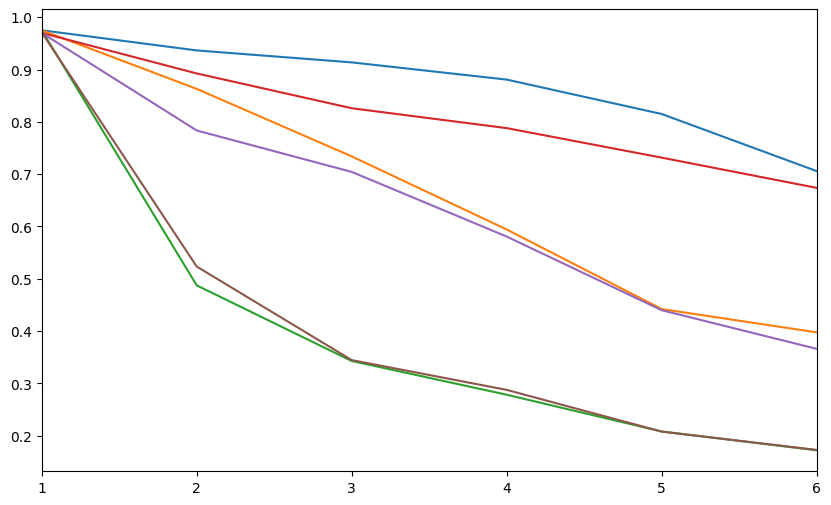

<Figure size 640x480 with 0 Axes>

In [34]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)

plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['succeeded'],
    std=std['succeeded'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Goal Success Rate",
)
fig.savefig('intersections_goal_success_rates.png', bbox_inches='tight')

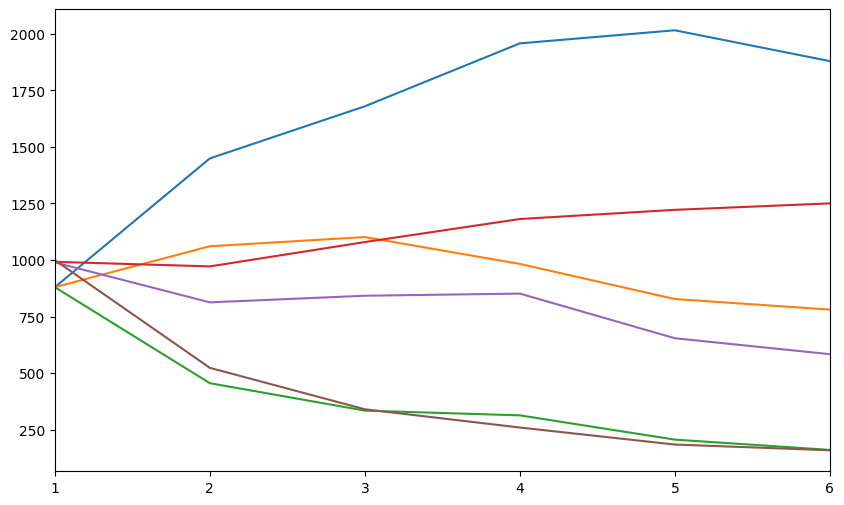

<Figure size 640x480 with 0 Axes>

In [35]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)

plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['distance_traveled'],
    std=std['distance_traveled'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Distance",
)
fig.savefig('intersections_avg_distance_traveled.png', bbox_inches='tight')

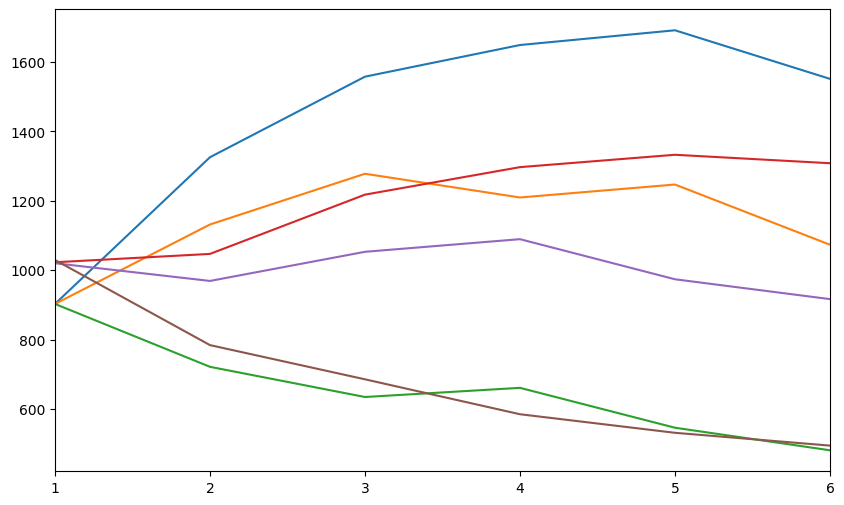

<Figure size 640x480 with 0 Axes>

In [36]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)

plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=dist_per_success_avg,
    std=dist_per_success_std,
    max_robots=max_robots,
    algs=algs,
    ylabel="Distance Per Successful Goal",
)
fig.savefig('intersections_avg_distance_traveled_per_success.png', bbox_inches='tight')

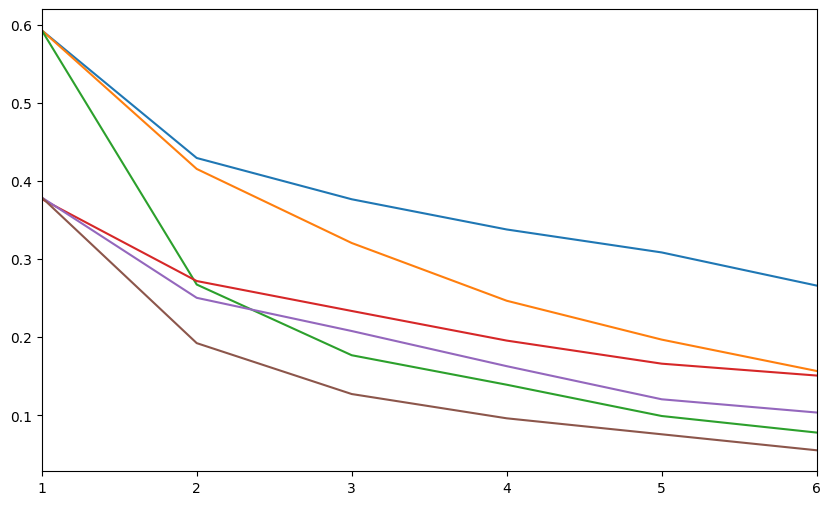

<Figure size 640x480 with 0 Axes>

In [37]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['n_transfers'],
    std=std['n_transfers'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Num Transfers",
)
fig.savefig('intersections_num_transfers.png', bbox_inches='tight')

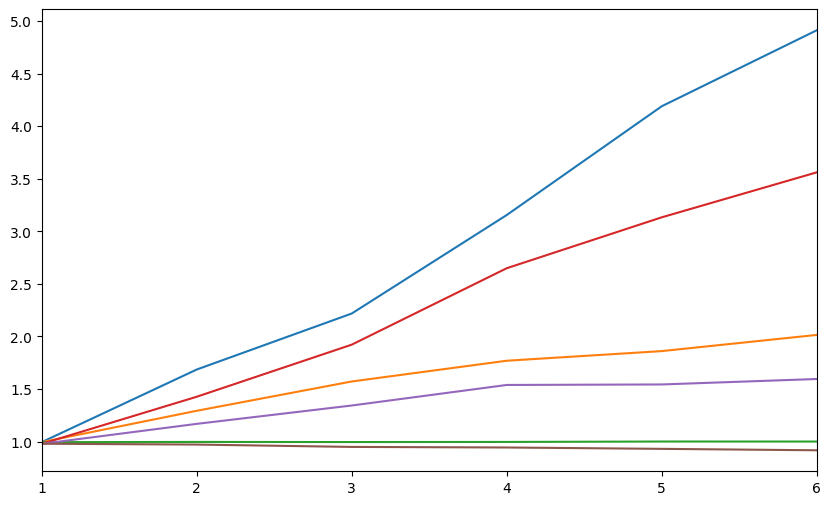

<Figure size 640x480 with 0 Axes>

In [38]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['replans'],
    std=std['replans'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Num Replans",
)
fig.savefig('intersections_num_replans.png', bbox_inches='tight')

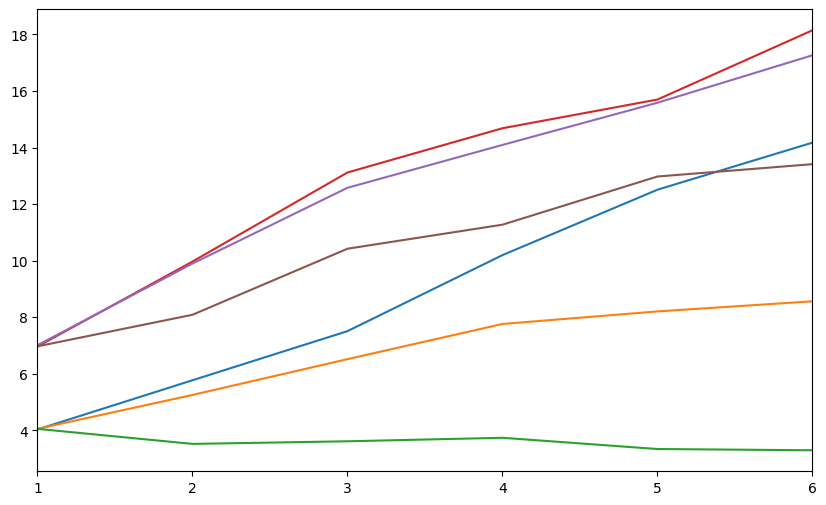

<Figure size 640x480 with 0 Axes>

In [39]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg['planning_time'],
    std=std['planning_time'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Planning Time",
)
fig.savefig('intersections_planning_time.png', bbox_inches='tight')

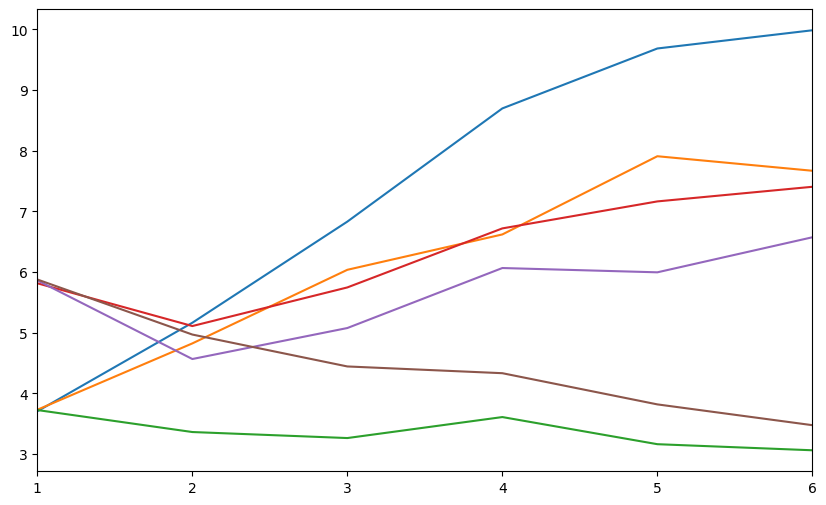

<Figure size 640x480 with 0 Axes>

In [40]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_success['planning_time'],
    std=avg_success['planning_time'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Planning Time",
)
fig.savefig('intersections_goal_planning_time_per_success.png', bbox_inches='tight')

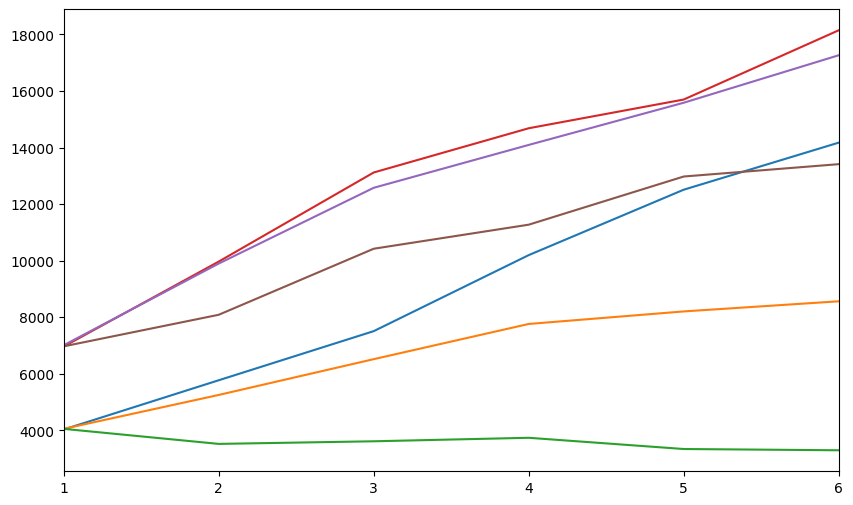

<Figure size 640x480 with 0 Axes>

In [41]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_per_sim['planning_time'],
    std=std_per_sim['planning_time'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Planning Time",
)
fig.savefig('intersections_sim_planning_time.png', bbox_inches='tight')

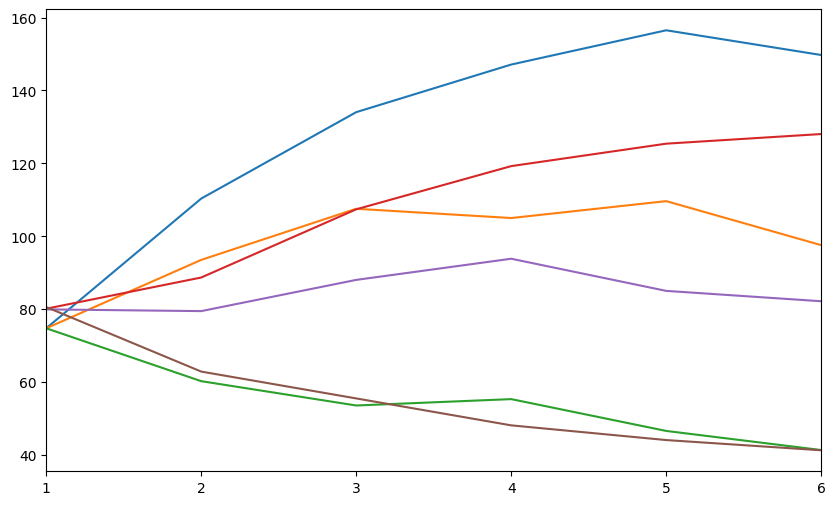

<Figure size 640x480 with 0 Axes>

In [42]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_success['n_steps'],
    std=std_success['n_steps'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Steps",
)
fig.savefig('intersections_steps.png', bbox_inches='tight')

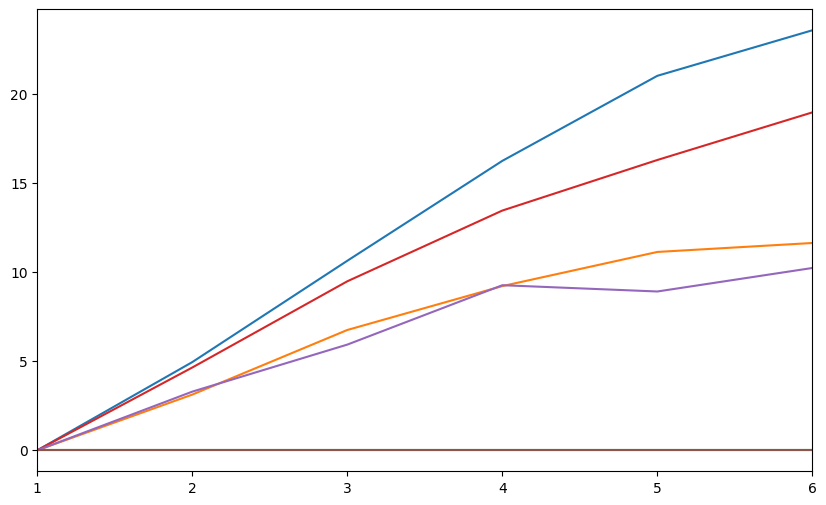

<Figure size 640x480 with 0 Axes>

In [43]:
fig = plt.figure(constrained_layout=False, figsize=(10,6))
gs = GridSpec(1, 1, figure=fig)
plot_metric_by_num_robots(
    ax=fig.add_subplot(gs[0, 0]),
    avg=avg_success['postponements'],
    std=std_success['postponements'],
    max_robots=max_robots,
    algs=algs,
    ylabel="Postponments",
)
fig.savefig('intersections_postpones.png', bbox_inches='tight')